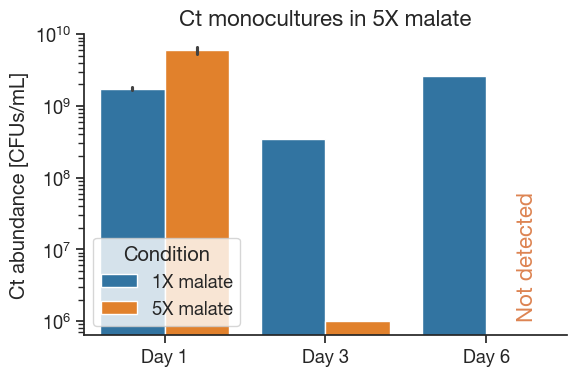

In [47]:
from pathlib import Path

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
sns.set_theme(context="notebook", style="ticks", font="Helvetica Neue", font_scale=1.2)

# Load monoculture table
csv_path = Path('../..') / 'data' / '3_second_community_assembly' / '5x_malate_ct_monoculture.csv'
df = pd.read_csv(csv_path)

# Convert CFU to numeric (ND and blanks become NaN)
df['CFU_per_mL'] = pd.to_numeric(df['CFU_per_mL'], errors='coerce')
df = df.iloc[1:]
df = df.loc[df['Condition'].isin(['1X malate', '5X malate'])]
# Plot bar chart of CFU by condition
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=df,
    x='Time',
    y='CFU_per_mL',
    hue='Condition',
    hue_order=['1X malate', '5X malate'],
    estimator='mean',
    errorbar='sd',
    palette='tab10'
)
plt.legend(title='Condition', loc='lower left', ncol=1)
# plt.xticks(rotation=30, ha='right')
plt.yscale('log')
plt.ylabel('Ct abundance [CFUs/mL]')
plt.xlabel('')
plt.title('Ct monocultures in 5X malate', fontsize=16)

# Annotate missing Day 6 / 5X malate measurement (ND in source table)
time_positions = {tick.get_text(): i for i, tick in enumerate(ax.get_xticklabels())}
if 'Day 6' in time_positions:
    day6_x = time_positions['Day 6']
    # With 3 hues and dodged bars, the right-most bar center is near +0.27
    ax.text(
        day6_x + 0.25,
        1e6,
        'Not detected',
        ha='center',
        va='bottom',
        fontsize=16,
        rotation=90,
        color='C1',
        fontweight='bold'
    )

plt.tight_layout()
sns.despine()
plt.show()

